# K-means clustering

In this section you will create clusters based on book ratings using K-means operations. 

Are there similarities between books when we plot them in a graph? Are there possible clusters we can derive from this spatial layout? 

To help us cluster our book data, we will be using the sklearn Kmeans and a graph layout function from Ch.7 in our manual. 

## 1. Load the dataset

In [1]:
# code goes here
import pandas as pd 
df = pd.read_csv('data/BX-Book-Ratings-Filtered.csv', sep=';', encoding='latin-1')
df

,User-ID,ISBN,Book-Rating
0,4017,006000438X,10
1,4017,0060915544,8
2,4017,0060929871,9
3,4017,0060930187,10
4,4017,0060964049,9
...,...,...,...
11360,276050,0553377868,7
11361,276050,0671021001,9
11362,276050,067102423X,8
11363,276050,0679746048,7


## 1. Construct a ratings matrix 

To cluster our data we need to construct a matrix where each row is the ratings from all users for a certain book. In other words, the index of the matrix will be books ISBN and the columns user ratings (i.e., one column per User-ID).

Can you construct such (huge!) matrix with the dataset? (Hint: use the pandas dataframe `pivot` function)

In [2]:
# code goes here
ratings_matrix = df.pivot(index="ISBN", columns="User-ID", values="Book-Rating")
ratings_matrix

User-ID,4017,6242,6251,6543,6563,6575,7346,8067,8245,8253,...,270713,271195,271448,271558,271705,273113,274004,274061,274301,276050
ISBN,,,,,,,,,,,,,,,,,,,,,
002542730X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
006000438X,10.0,6.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0060096195,NaN,NaN,NaN,NaN,NaN,NaN,8.0,10.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
006016848X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0060173289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573229571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1573229725,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1576737330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.  Construct a sparse matrix using scipy.sparse

Now that you have a matrix built from the dataset we need to tranform it into a `scipy.sparse` `csr_matrix` in order to produce our clusters with `sklearn.cluster`

In [3]:
from scipy.sparse import csr_matrix
sparse_ratings_matrix = csr_matrix(ratings_matrix.fillna(0))

# Display the sparse matrix properties
sparse_ratings_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11365 stored elements and shape (832, 342)>

## 3. Cluster!

Now that you have your matrix ready it is time to cluster! 

Can you fit your matrix into the 3x clusters Kmeans object?  

In [7]:
from sklearn.cluster import KMeans

kmeans_3_clusters = KMeans(n_clusters=3)

clusters = kmeans_3_clusters.fit_predict(sparse_ratings_matrix)

ratings_matrix["Cluster"] = clusters
ratings_matrix.head(10)


User-ID,4017,6242,6251,6543,6563,6575,7346,8067,8245,8253,...,271195,271448,271558,271705,273113,274004,274061,274301,276050,Cluster
ISBN,,,,,,,,,,,,,,,,,,,,,
002542730X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
006000438X,10.0,6.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
0060096195,NaN,NaN,NaN,NaN,NaN,NaN,8.0,10.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
006016848X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
0060173289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,2
0060199652,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
0060248025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
0060391626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
0060392452,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN,1


What does the  `clusters ` variable hold in terms of data?

## 4. Visualise clusters

Below is a (modified) `plot` function from our manual discussed in Ch.7. section 7.4.2. It displays clusters in a graph. 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot(user_ratings, k):

        h = 0.2
        reduced_data = PCA(n_components=2).fit_transform(user_ratings)

        kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10)
        kmeans.fit(reduced_data)

        x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
        y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)

        plt.figure(1)
        plt.clf()
        plt.imshow(Z, interpolation='nearest',
                   extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                   cmap=plt.cm.Paired,
                   aspect='auto', origin='lower')

        centroids = kmeans.cluster_centers_
        plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=2)
        plt.scatter(centroids[:, 0], centroids[:, 1],
                    marker='x', s=169, linewidths=3,
                    color='r', zorder=10)
        plt.title('K-means clustering of the user')

Let's use this function to see how our books data can be clustered.  

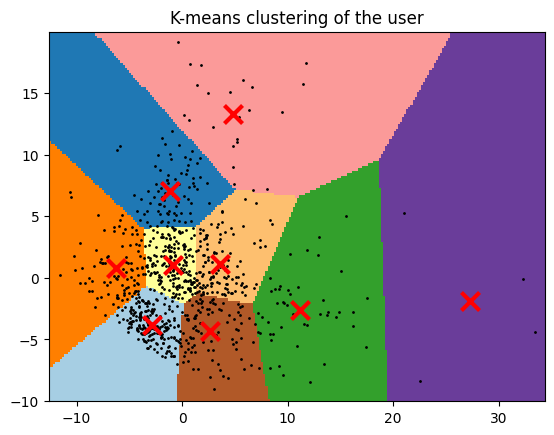

In [14]:
from scipy.sparse import dok_matrix
# Construct the ratings matrix
ratings_matrix = df.pivot(index="ISBN", columns="User-ID", values="Book-Rating")

# Convert the ratings matrix to a sparse matrix (CSR format)
sparse_ratings_matrix = csr_matrix(ratings_matrix.fillna(0))
d_matrix = np.asarray(dok_matrix(sparse_ratings_matrix).todense())

plot(user_ratings=d_matrix, k=9)


## 5. How about users?

Can we you use the code above to cluster users depending on their ratings? Can you visualise this clustering using the `plot` function above?

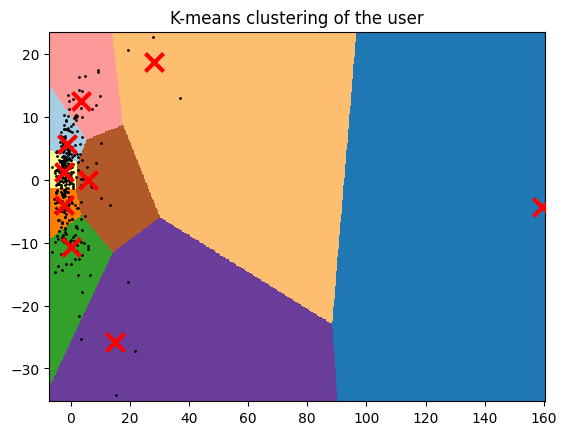

In [17]:
# code goes here
# Construct the ratings matrix (Users as columns, Books as rows)
ratings_matrix = df.pivot(index="User-ID", columns="ISBN", values="Book-Rating")

# Convert the ratings matrix to a sparse matrix (CSR format)
sparse_ratings_matrix = csr_matrix(ratings_matrix.fillna(0))

# Transpose the ratings matrix to cluster users instead of books
user_ratings_matrix = sparse_ratings_matrix.T
d_matrix = np.asarray(dok_matrix(sparse_ratings_matrix).todense())

plot(user_ratings=d_matrix, k=9)

## 6. Saving clusters

Create a dataframe consisting of 'User-ID' and cluster labels and save it in the data directory. To help you do this you can use the following code.

In [97]:
kmeans_3_clusters = KMeans(n_clusters=3)

clusters = kmeans_3_clusters.fit(...)

# code goes here